<a href="https://colab.research.google.com/github/dheep2305-git/Tsf-tasks/blob/main/tsf_task_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
     year  quarter   realgdp  realcons  realinv  realgovt  realdpi    cpi  \
0  1959.0      1.0  2710.349    1707.4  286.898   470.045   1886.9  28.98   
1  1959.0      2.0  2778.801    1733.7  310.859   481.301   1919.7  29.15   
2  1959.0      3.0  2775.488    1751.8  289.226   491.260   1916.4  29.35   
3  1959.0      4.0  2785.204    1753.7  299.356   484.052   1931.3  29.37   
4  1960.0      1.0  2847.699    1770.5  331.722   462.199   1955.5  29.54   

      m1  tbilrate  unemp      pop  infl  realint  
0  139.7      2.82    5.8  177.146  0.00     0.00  
1  141.7      3.08    5.1  177.830  2.34     0.74  
2  140.5      3.82    5.3  178.657  2.74     1.09  
3  140.0      4.33    5.6  179.386  0.27     4.06  
4  139.6      3.50    5.2  180.007  2.31     1.19  

Selected Data:
             realgdp  realcons  realinv
1959-03-31  2710.349    1707.4  286.898
1959-06-30  2778.801    1733.7  310.859
1959-09-30  2775.488    1751.8  289.226
1959-12-31  2785.204    1753.7  299.356


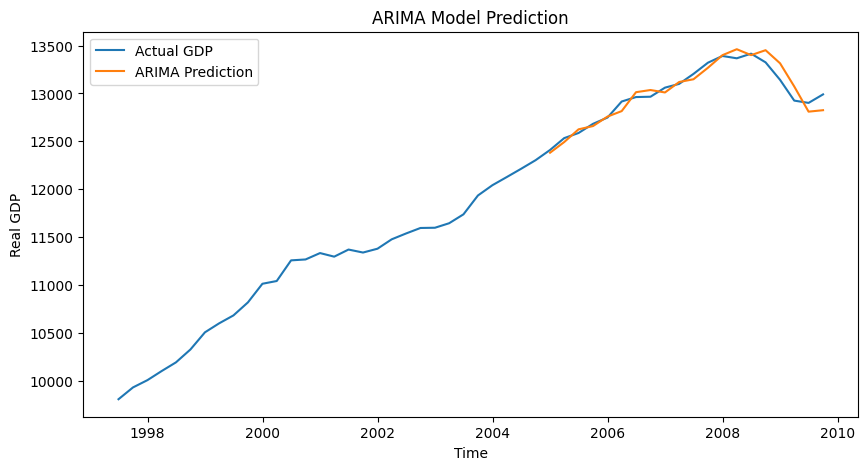


========== VAR MODEL ==========
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 27, Aug, 2026
Time:                     03:50:20
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    20.5675
Nobs:                     200.000    HQIC:                   20.3614
Log likelihood:          -2852.49    FPE:                6.05346e+08
AIC:                      20.2212    Det(Omega_mle):     5.45987e+08
--------------------------------------------------------------------
Results for equation realgdp
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              10.308143         6.425207            1.604           0.109
L1.realgdp         -0.394370         0.148481           -2.656           0.008
L1.realcons         1.185980     

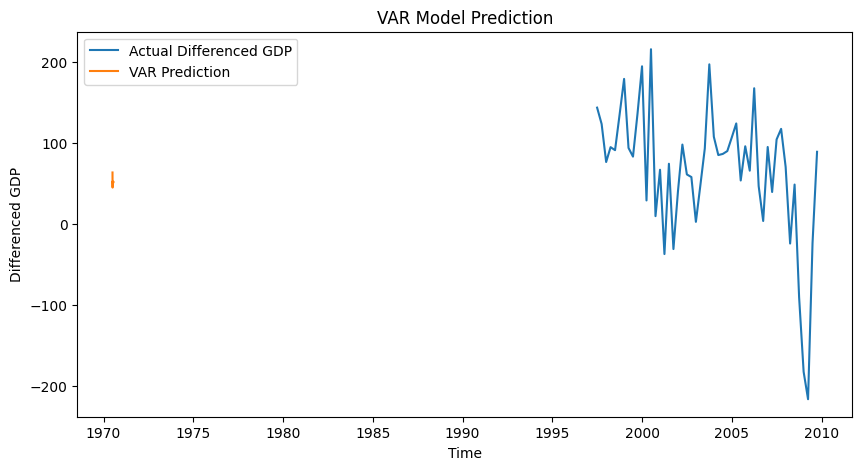

In [ ]:
# TASK 8
# Compare ARIMA and VAR Models

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.datasets import macrodata

# Step 2: Load Dataset
data = macrodata.load_pandas().data

print("Dataset:")
print(data.head())

# Step 3: Create Time Index
dates = pd.date_range(
    start='1959',
    periods=len(data),
    freq='QE'
)

data.index = dates

# Select required variables
df = data[['realgdp', 'realcons', 'realinv']]

print("\nSelected Data:")
print(df.head())

# Step 4: Differencing
df_diff = df.diff().dropna()

print("\nDifferenced Data:")
print(df_diff.head())

# -------------------------------------------------
# ARIMA MODEL
# -------------------------------------------------

# Step 5: Fit ARIMA model on real GDP
arima_model = ARIMA(
    df['realgdp'],
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print("\n========== ARIMA MODEL ==========")
print(arima_fit.summary())

# Generate ARIMA predictions
arima_pred = arima_fit.predict(
    start=len(df) - 20,
    end=len(df) - 1
)

# Graph 1: ARIMA
plt.figure(figsize=(10, 5))

plt.plot(
    df['realgdp'][-50:],
    label='Actual GDP'
)

plt.plot(
    arima_pred,
    label='ARIMA Prediction'
)

plt.title('ARIMA Model Prediction')
plt.xlabel('Time')
plt.ylabel('Real GDP')
plt.legend()
plt.show()


# -------------------------------------------------
# VAR MODEL
# -------------------------------------------------

# Step 6: Fit VAR model
var_model = VAR(df_diff)

var_fit = var_model.fit(maxlags=2)

print("\n========== VAR MODEL ==========")
print(var_fit.summary())

# Step 7: Generate VAR Forecast
var_pred = var_fit.forecast(
    df_diff.values[-2:],
    steps=20
)

# Convert predictions to DataFrame
var_pred_df = pd.DataFrame(
    var_pred,
    columns=df_diff.columns
)

print("\nVAR Predictions:")
print(var_pred_df)


# -------------------------------------------------
# GRAPH: VAR
# -------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df_diff['realgdp'][-50:],
    label='Actual Differenced GDP'
)

plt.plot(
    range(len(df_diff) - 20, len(df_diff)),
    var_pred_df['realgdp'],
    label='VAR Prediction'
)

plt.title('VAR Model Prediction')
plt.xlabel('Time')
plt.ylabel('Differenced GDP')
plt.legend()
plt.show()